In [57]:
import numpy as np 
import faiss
import sys
import time
import csv
import os
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from numba import jit, prange
import threading
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

module_path = '/home/cpanourg/projects/2-hdvc/'

if module_path not in sys.path:
    sys.path.append(module_path)

from src.utils import read_fvecs
from src.utils import append_or_create_csv
from src.utils import compute_distance_tables_threaded, compute_distance_tables_vectorized, adc_distances_batch_numba\
                    , compute_all_distances_batch, adc_distances_all_optimized, lsq_alpha_from_codes \
                    , lsq_dot_tables_vectorized, lsq_distances_batch_numba
  



In [58]:
root = "mnthdd" # thalia 
# root = "data" # urania

dataset_name = 'gist'
data_fp = f"/{root}/cpanourg/2-hdvc/data/"

# Loading the GIST dataset
db = np.array(read_fvecs(f'{data_fp}gist/gist_base.fvecs'))
qr = np.array(read_fvecs(f'{data_fp}gist/gist_query.fvecs'))


dim = db.shape[1]
nbits = dim 

Reading File - /mnthdd/cpanourg/2-hdvc/data/gist/gist_base.fvecs:(1000000, 960)
Reading File - /mnthdd/cpanourg/2-hdvc/data/gist/gist_query.fvecs:(1000, 960)


In [59]:
import os, numpy as np

def fvecs_info(path):
    with open(path, "rb") as f:
        d = np.fromfile(f, dtype=np.int32, count=1)[0]
    rec_bytes = (d + 1) * 4
    n = os.path.getsize(path) // rec_bytes
    return int(n), int(d), rec_bytes

def fvecs_read_chunk(path, start, count, d):
    rec = d + 1
    a = np.fromfile(path, dtype=np.int32, count=count*rec, offset=start*rec*4)
    a = a.reshape(-1, rec)
    return a[:, 1:].view(np.float32)  # returns a copy

def compute_centroid_fvecs(path, chunk=200_000):
    n, d, _ = fvecs_info(path)
    s = np.zeros(d, dtype=np.float64)   # accumulate in float64 for accuracy
    done = 0
    for i0 in range(0, n, chunk):
        m = min(chunk, n - i0)
        X = fvecs_read_chunk(path, i0, m, d)  # [m, d] float32
        s += X.sum(axis=0, dtype=np.float64)
        done += m
        # (optional) print progress
        # print(f"{done}/{n}")
    c = (s / done).astype(np.float32)
    return c




learn_path = f"{data_fp}gist/gist_learn.fvecs"  # <- your path

start = time.time()
centroid = compute_centroid_fvecs(learn_path)
centroid_calc_time = time.time() - start 
np.save(f"{data_fp}gist/centroid.npy", centroid)
print("Saved centroid.npy with shape", centroid.shape)
print(f"Time = {centroid_calc_time}")

Saved centroid.npy with shape (960,)
Time = 5.674299478530884


In [62]:
import os
import numpy as np
from ctypes import CDLL, c_int64, c_float, c_uint8, c_int, POINTER

# -----------------------------
# 1.  Paths and environment
# -----------------------------
FAISS_LIB = os.path.expanduser("~/projects/2-hdvc/lib/faiss/build/faiss")
SHIM_SO   = os.path.expanduser("~/projects/2-hdvc/lib/faiss_lib_mine/build/librbqshim.so")
os.environ["LD_LIBRARY_PATH"] = FAISS_LIB + ":" + os.environ.get("LD_LIBRARY_PATH","")

# DATA_DIR = "/data/cpanourg/2-hdvc/data/gist"
DATA_DIR = "/mnthdd/cpanourg/2-hdvc/data/gist"
base_fvecs = f"{DATA_DIR}/gist_base.fvecs"
centroid_path = f"{DATA_DIR}/centroid.npy"
out_codes_path = f"{DATA_DIR}/gist_base.fvecs.rbq.codes.u8"

# -----------------------------
# 2.  Load library and define signatures
# -----------------------------
lib = CDLL(SHIM_SO)

lib.rbq_code_size.argtypes = [c_int64]
lib.rbq_code_size.restype  = c_int64

lib.rbq_encode_batch.argtypes = [
    POINTER(c_float),  # X*
    c_int64, c_int64,  # n, d
    POINTER(c_float),  # centroid*
    POINTER(c_uint8),  # codes*
    c_int              # metric_type (0=L2, 1=IP)
]
lib.rbq_encode_batch.restype = c_int

# -----------------------------
# 3.  fvecs readers
# -----------------------------
def fvecs_info(path):
    with open(path, "rb") as f:
        d = np.fromfile(f, dtype=np.int32, count=1)[0]
    rec_bytes = (d + 1) * 4
    n = os.path.getsize(path) // rec_bytes
    return int(n), int(d), rec_bytes

def fvecs_read_chunk(path, start, count, d):
    rec = d + 1
    a = np.fromfile(path, dtype=np.int32, count=count * rec, offset=start * rec * 4)
    a = a.reshape(-1, rec)
    return a[:, 1:].view(np.float32).copy()

# -----------------------------
# 4.  Encode the dataset
# -----------------------------
def encode_dataset(fvecs_path, centroid_path, out_path, chunk_size=100_000, metric_type=0):
    n, d, _ = fvecs_info(fvecs_path)
    print(f"Dataset: {n} vectors, dimension {d}")

    # Load centroid
    centroid = np.load(centroid_path).astype(np.float32)
    centroid_p = centroid.ctypes.data_as(POINTER(c_float))

    # Get code size per vector
    code_size = int(lib.rbq_code_size(d))
    print(f"Each code = {code_size} bytes")

    # Create/overwrite output file
    if os.path.exists(out_path):
        os.remove(out_path)

    done = 0
    for i0 in range(0, n, chunk_size):
        m = min(chunk_size, n - i0)
        X = fvecs_read_chunk(fvecs_path, i0, m, d)
        X_p = X.ctypes.data_as(POINTER(c_float))

        codes = np.empty((m, code_size), dtype=np.uint8)
        codes_p = codes.ctypes.data_as(POINTER(c_uint8))

        ret = lib.rbq_encode_batch(X_p, m, d, centroid_p, codes_p, metric_type)
        if ret != 0:
            raise RuntimeError(f"rbq_encode_batch failed at batch {i0//chunk_size} (code {ret})")

        # Append to file
        with open(out_path, "ab") as f:
            codes.tofile(f)

        done += m
        print(f"Encoded {done}/{n} vectors ({100*done/n:.1f}%)")

    print(f"✅ Finished encoding {n} vectors → {out_path}")
    print(f"Total size on disk: {os.path.getsize(out_path)/1e6:.2f} MB")

# -----------------------------
# 5.  Run
# -----------------------------
if __name__ == "__main__":
    start = time.time()
    encode_dataset(base_fvecs, centroid_path, out_codes_path)
    encode_time = time.time() - start 
    print(f"Encoding Time = {encode_time}")

Dataset: 1000000 vectors, dimension 960
Each code = 128 bytes
Encoded 100000/1000000 vectors (10.0%)
Encoded 200000/1000000 vectors (20.0%)
Encoded 300000/1000000 vectors (30.0%)
Encoded 400000/1000000 vectors (40.0%)
Encoded 500000/1000000 vectors (50.0%)
Encoded 600000/1000000 vectors (60.0%)
Encoded 700000/1000000 vectors (70.0%)
Encoded 800000/1000000 vectors (80.0%)
Encoded 900000/1000000 vectors (90.0%)
Encoded 1000000/1000000 vectors (100.0%)
✅ Finished encoding 1000000 vectors → /mnthdd/cpanourg/2-hdvc/data/gist/gist_base.fvecs.rbq.codes.u8
Total size on disk: 128.00 MB
Encoding Time = 18.15350842475891


In [41]:
import os, math, numpy as np
from ctypes import CDLL, c_int, c_int64, c_float, c_uint8, POINTER

# ---- paths
FAISS_LIB = os.path.expanduser("~/projects/2-hdvc/lib/faiss/build/faiss")
SHIM_SO   = os.path.expanduser("~/projects/2-hdvc/lib/faiss_lib_mine/build/librbqshim.so")
os.environ["LD_LIBRARY_PATH"] = FAISS_LIB + ":" + os.environ.get("LD_LIBRARY_PATH","")

# ---- load shim & declare signatures
lib = CDLL(SHIM_SO)

lib.rbq_code_size.argtypes = [c_int64]
lib.rbq_code_size.restype  = c_int64

lib.rbq_l2_distances_qbits.argtypes = [
    POINTER(c_float), c_int64,             # query*, d
    POINTER(c_uint8), c_int64,             # codes*, n
    POINTER(c_float),                      # centroid*
    c_int, c_int, c_int,                   # qb, centered, metric (0=L2, 1=IP)
    POINTER(c_float)                       # out distances*
]
lib.rbq_l2_distances_qbits.restype = c_int

# ---- helpers
def load_codes(path, d):
    code_size = int(lib.rbq_code_size(d))
    # code_size = 128  # for 8 bits
    nbytes_bits = (d + 7) // 8
    fsz = os.path.getsize(path)
    n = fsz // code_size
    codes_mm = np.memmap(path, dtype=np.uint8, mode="r", shape=(n, code_size))
    return codes_mm, code_size, n, nbytes_bits

def read_fvecs(path, start=0, count=None):
    a0 = np.fromfile(path, dtype=np.int32, count=1)
    d = int(a0[0]); rec = d+1
    # d = 8
    if count is None:
        count = (os.path.getsize(path)//4)//rec
    a = np.fromfile(path, dtype=np.int32, count=count*rec, offset=start*rec*4)
    a = a.reshape(-1, rec)
    return a[:,1:].view(np.float32).copy(), d

# ---- your files
base_codes_path = f"{data_fp}gist/gist_base.fvecs.rbq.codes.u8"    # produced earlier
centroid = np.load(f"{data_fp}gist/centroid.npy").astype(np.float32)  # or compute earlier
queries_path = f"{data_fp}gist/gist_query.fvecs"

# load queries
Q, d = read_fvecs(queries_path)  
centroid_p = centroid.ctypes.data_as(POINTER(c_float))

# load codes memmap
codes_mm, code_size, nb, nbytes_bits = load_codes(base_codes_path, d)
print("DB:", nb, "vectors; d:", d, "code_size:", code_size, "nbytes_bits:", nbytes_bits)


DB: 1000000 vectors; d: 960 code_size: 128 nbytes_bits: 120


In [63]:
N = 10_000  # <-- only score the first N DB vectors

nq, d = Q.shape
nb = codes_mm.shape[0]
nb_eff = min(N, nb)

dist_mm = np.memmap(
    f"/{root}/cpanourg/2-hdvc/results/rabitq/rbq_dists_firstN.f32",
    dtype=np.float32, mode="w+", shape=(nq, nb_eff)
)

db_block = 400_000
qb, centered, metric = 8, 0, 0
tmp = np.empty(db_block, dtype=np.float32)

def dists_one_query_into(q, codes_block, out_view):
    m = codes_block.shape[0]
    rc = lib.rbq_l2_distances_qbits(
        q.ctypes.data_as(POINTER(c_float)), c_int64(d),
        codes_block.ctypes.data_as(POINTER(c_uint8)), c_int64(m),
        centroid.ctypes.data_as(POINTER(c_float)),
        c_int(qb), c_int(centered), c_int(metric),
        tmp.ctypes.data_as(POINTER(c_float))
    )
    if rc != 0:
        raise RuntimeError(f"rbq distances rc={rc}")
    out_view[:] = tmp[:m]

start = time.time()
blocks = math.ceil(nb_eff / db_block)
for b in range(blocks):
    i0 = b * db_block
    i1 = min(nb_eff, i0 + db_block)
    codes_block = codes_mm[i0:i1]  # only the first N
    for qi in range(nq):
        dists_one_query_into(Q[qi], codes_block, dist_mm[qi, i0:i1])
    print(f"[block {b+1}/{blocks}] wrote cols {i0}:{i1}")
dist_mm.flush()
print("Wrote:", dist_mm.filename)

dist_comp_time = time.time() - start 
print(f'dist calc time = {dist_comp_time}')

[block 1/1] wrote cols 0:10000
Wrote: /mnthdd/cpanourg/2-hdvc/results/rabitq/rbq_dists_firstN.f32
dist calc time = 7.5330116748809814


In [ ]:
# import math, time, os
# from concurrent.futures import ThreadPoolExecutor, as_completed

# start = time.time()
# blocks = math.ceil(nb_eff / db_block)
# n_threads = os.cpu_count() or 8  # use all available CPU cores

# def process_one_query(qi, codes_block, i0, i1):
#     """Compute distances for one query in current block."""
#     dists_one_query_into(Q[qi], codes_block, dist_mm[qi, i0:i1])

# for b in range(blocks):
#     i0 = b * db_block
#     i1 = min(nb_eff, i0 + db_block)
#     codes_block = codes_mm[i0:i1]

#     # run queries in parallel across CPU cores
#     with ThreadPoolExecutor(max_workers=n_threads) as executor:
#         futures = [
#             executor.submit(process_one_query, qi, codes_block, i0, i1)
#             for qi in range(nq)
#         ]
#         # wait for completion, optional progress
#         for fi, f in enumerate(as_completed(futures), 1):
#             if fi % max(1, nq // 10) == 0:
#                 print(f"  done {fi}/{nq} queries...", end="\r")
    
#     print(f"[block {b+1}/{blocks}] wrote cols {i0}:{i1}")

# dist_mm.flush()
# print("Wrote:", dist_mm.filename)

# dist_comp_time = time.time() - start
# print(f"dist calc time = {dist_comp_time:.2f}s using {n_threads} threads")


[block 1/1] wrote cols 0:10000
Wrote: /mnthdd/cpanourg/2-hdvc/results/rabitq/rbq_dists_firstN.f32
dist calc time = 3.06s using 80 threads


In [43]:
import os, numpy as np

path = f"/{root}/cpanourg/2-hdvc/results/rabitq/rbq_dists_firstN.f32"

def load_distances(path, nq=None, nb=None):
    """Return a float32 memmap of shape (nq, nb)."""
    bytes_per_f32 = 4
    size_bytes = os.path.getsize(path)
    n_floats = size_bytes // bytes_per_f32
    if nq is None and nb is None:
        raise ValueError("Provide at least one of (nq, nb).")
    if nq is None:
        if n_floats % nb != 0:
            raise ValueError("File size not divisible by nb.")
        nq = n_floats // nb
    if nb is None:
        if n_floats % nq != 0:
            raise ValueError("File size not divisible by nq.")
        nb = n_floats // nq
    return np.memmap(path, dtype=np.float32, mode="r", shape=(nq, nb))

nq = 1000
D = load_distances(path, nq=nq, nb=N)

print(D.shape)            # (1000, 250000)
print(D.dtype)            # float32


(1000, 10000)
float32


In [44]:
D

memmap([[3.45963, 2.72104, 4.36406, ..., 2.06526, 1.56114, 5.92307],
        [2.29703, 1.95834, 3.02177, ..., 1.55824, 1.92271, 4.4407 ],
        [2.91712, 3.03899, 4.96955, ..., 1.93438, 1.76616, 6.6864 ],
        ...,
        [3.7558 , 2.33604, 3.00827, ..., 2.27354, 2.25472, 3.36367],
        [3.75258, 2.79206, 4.65703, ..., 2.08274, 1.70232, 4.47866],
        [2.94729, 3.24831, 4.45809, ..., 1.35015, 1.39995, 4.64957]],
       dtype=float32)

In [45]:
# Exact distances with cdist

t0 = time.time()
exact_sample = cdist(qr, db[:10000], metric="sqeuclidean").astype(np.float32)
cdist_time = time.time() - t0
time.time() - t0
print(f"Time to compute exact distances: {cdist_time} seconds")

Time to compute exact distances: 46.82443404197693 seconds


In [46]:
exact_sample

array([[4.53871, 3.13959, 5.48577, ..., 2.2722 , 1.82061, 6.48726],
       [3.41511, 2.12565, 3.667  , ..., 1.67902, 2.20642, 4.994  ],
       [4.76085, 3.62529, 6.31579, ..., 2.3211 , 2.11891, 7.61686],
       ...,
       [4.19128, 2.37005, 3.77908, ..., 2.13866, 2.33361, 3.85432],
       [4.64732, 3.01347, 5.62077, ..., 2.37883, 1.84327, 5.27314],
       [5.12613, 3.89695, 6.2971 , ..., 1.81359, 1.89352, 6.44681]],
      dtype=float32)

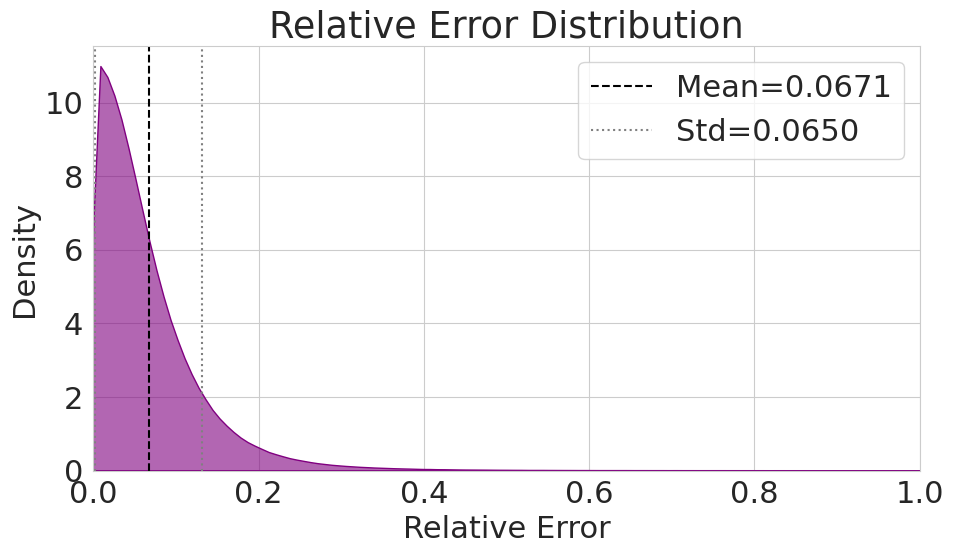

In [47]:

plt.rcParams['font.family'] = 'serif'
sns.set_style("whitegrid")
# Relative errors
rel_error = np.abs(D - exact_sample) / (exact_sample + 1e-12)
rel_error.astype(np.float32).tofile(f'/{root}/cpanourg/2-hdvc/results/rabitq/rel_error.bin')
mean_rel, std_rel = rel_error.mean(), rel_error.std()

# Plot KDE of relative errors
rel_error_flat = rel_error.ravel()
plt.figure(figsize=(10, 6))
plt.xlim(0, 1)
sns.kdeplot(rel_error_flat, fill=True, color="purple", alpha=0.6)
plt.axvline(mean_rel, linestyle="--", color="black", label=f"Mean={mean_rel:.4f}")
plt.axvline(mean_rel-std_rel, linestyle=":", color="grey")
plt.axvline(mean_rel+std_rel, linestyle=":", color="grey", label=f"Std={std_rel:.4f}")
plt.title(f"Relative Error Distribution")
plt.xlabel("Relative Error")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# print(f"[cdist] sample {len(q_idx)} queries x {len(db_idx)} DB: {cdist_time:.3f}s")
# print(f"Mean relative error={mean_rel:.6f}, Std={std_rel:.6f}")


In [33]:
nq, nb, dataset_name, dim, encode_time + centroid_calc_time

(1000, 1000000, 'gist', 960, 27.61442518234253)

In [55]:

summary = {
    "method": "RaBitQ",
    "dataset": dataset_name,
    "nq": nq,
    "nb": nb,
    "nb_sample": N,
    "dim": dim,
    "n_subquantizers": "None",
    "nbits": nbits,
    "bits_per_vector": nbits,
    # "k": k,
    "train_ratio": 0,
    "train_size": 0,
    "train_time_s": float(0),
    "encoding_time_s": float(encode_time + centroid_calc_time),
    "distance_table_time_s": float(0),
    "cdist_time_s": float(cdist_time),
    "adc_time_s": float(dist_comp_time),
    "rel_error_mean": float(mean_rel),
    "rel_error_std": float(std_rel),

}
csv_path=f"/{root}/cpanourg/2-hdvc/results/adc_vs_exact_eval.csv"

need_header = not Path(csv_path).exists() or Path(csv_path).stat().st_size == 0
with open(csv_path, "a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(summary.keys()))
    if need_header:
        writer.writeheader()
    writer.writerow(summary)


In [56]:
import pandas as pd

pd.read_csv(f"/{root}/cpanourg/2-hdvc/results/adc_vs_exact_eval.csv").round(4)


,method,dataset,nq,nb,nb_sample,dim,n_subquantizers,nbits,bits_per_vector,train_ratio,train_size,train_time_s,encoding_time_s,distance_table_time_s,cdist_time_s,adc_time_s,rel_error_mean,rel_error_std
0,PQ,GIST,1000,1000000,10000,960,120.0,8,960,0.1,100000,16.5878,1.1888,0.941,6.6872,0.0938,0.0880,0.0597
1,OPQ,GIST,1000,1000000,10000,960,120.0,8,960,0.1,100000,108.0316,1.5467,0.820,6.1952,1.0706,0.0319,0.0297
2,RaBitQ,gist,1000,1000000,10000,960,NaN,960,960,0.0,0,0.0000,22.7407,0.000,46.8244,14.7467,0.0671,0.0650
